# v11 Model Interpretability Explorer

**Goal:** Answer the *how* and *why* questions about our causal role classifier.

## What we extract:

### Part 1 — Static Weight Analysis (no GPU needed)
1. **Structural bias embeddings** — 6 types × 4 heads = 24 learned topological priors
2. **Stem layer weights** — how the 8 input channels are weighted
3. **Conv1d filter analysis** — what spatial patterns each block detects
4. **Edge type embeddings** — which directed edge types the model treats as similar
5. **Node head decomposition** — which edge directions matter per class

### Part 2 — Activation Analysis (requires inference pass)
6. **t-SNE of node embeddings** — class separability in embedding space
7. **Per-class activation fingerprints** — mean activation + Fisher discriminability
8. **Inter-class embedding distances** — cosine distance matrix + dendrogram

In [1]:
import os
import sys
import pickle
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
from collections import defaultdict

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [2]:
# ============================================================
# CONFIG — adjust these
# ============================================================
SRC_DIR = Path(".").resolve()  # run from src/
MODEL_PATH = SRC_DIR / "resources" / "model_v11_structbias.pt"
OUTPUT_DIR = SRC_DIR / "explore_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_DIR = SRC_DIR / "data"
X_TEST_PATH = DATA_DIR / "X_test_reduced.pickle"
Y_TEST_PATH = DATA_DIR / "y_test_reduced.pickle"

# Which v11 module to import from
V11_MODULE = "v11_structbias_xyaug"  # adjust if needed

N_CLASSES = 8
CLASS_NAMES = [
    "Confounder", "Collider", "Mediator",
    "Cause of X", "Cause of Y",
    "Consequence of X", "Consequence of Y",
    "Independent",
]

STRUCT_TYPE_NAMES = [
    "Reverse pair",      # 0: u1=v2 AND v1=u2
    "Shared source",     # 1: u1=u2
    "Shared target",     # 2: v1=v2
    "Forward chain",     # 3: v1=u2
    "Backward chain",    # 4: u1=v2
    "Unrelated",         # 5: none
]

CHANNEL_NAMES = [
    "sorted_obs_src",
    "sorted_obs_tgt",
    "kernel_bw0.2",
    "kernel_bw0.5",
    "kernel_bw1.0",
    "anm_resid_bw0.2",
    "anm_resid_bw0.5",
    "anm_resid_bw1.0",
]

EDGE_TYPE_NAMES = [
    "0: no edge",
    "1: generic edge",
    "2: X→*",
    "3: *→X",
    "4: Y→*",
    "5: *→Y",
    "6: X↔Y",
]

MAX_TSNE_SAMPLES = 5000
MAX_BATCHES = 200

In [3]:
def load_model_weights(model_path: Path) -> dict:
    """Load state dict, stripping 'model.' and 'module.' prefixes."""
    state = torch.load(model_path, map_location="cpu", weights_only=True)
    clean = {}
    for k, v in state.items():
        k = k.removeprefix("model.").removeprefix("module.")
        clean[k] = v
    return clean

# Load
assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
state_dict = load_model_weights(MODEL_PATH)
print(f"Loaded {len(state_dict)} parameter tensors")
print()

# Print all keys
total_params = sum(v.numel() for v in state_dict.values())
print(f"Total parameters: {total_params:,}\n")
for k, v in sorted(state_dict.items()):
    print(f"  {k:50s} {str(list(v.shape)):>20s}  ({v.numel():>7,})")

Loaded 64 parameter tensors

Total parameters: 188,730

  attn_layers.0.ff.0.bias                                           [256]  (    256)
  attn_layers.0.ff.0.weight                                     [256, 64]  ( 16,384)
  attn_layers.0.ff.2.bias                                            [64]  (     64)
  attn_layers.0.ff.2.weight                                     [64, 256]  ( 16,384)
  attn_layers.0.k_proj.bias                                          [64]  (     64)
  attn_layers.0.k_proj.weight                                    [64, 64]  (  4,096)
  attn_layers.0.norm1.bias                                           [64]  (     64)
  attn_layers.0.norm1.weight                                         [64]  (     64)
  attn_layers.0.norm2.bias                                           [64]  (     64)
  attn_layers.0.norm2.weight                                         [64]  (     64)
  attn_layers.0.out_proj.bias                                        [64]  (     64)
  attn_la

---
# Part 1: Static Weight Analysis

## 1. Structural Attention Bias

The model's **domain prior**: 6 topological relationship types × 4 attention heads = 24 learnable scalars.

These biases are added to attention logits *before* softmax. Positive bias = "pay more attention to edges with this relationship." Negative = "suppress attention."

**Key questions:**
- Does forward-chain (type 3) get positive bias? (needed for Mediator detection)
- Do reverse pairs (type 0) get strong bias? (the model's self-edge awareness)
- Do different heads specialize in different relationship types?

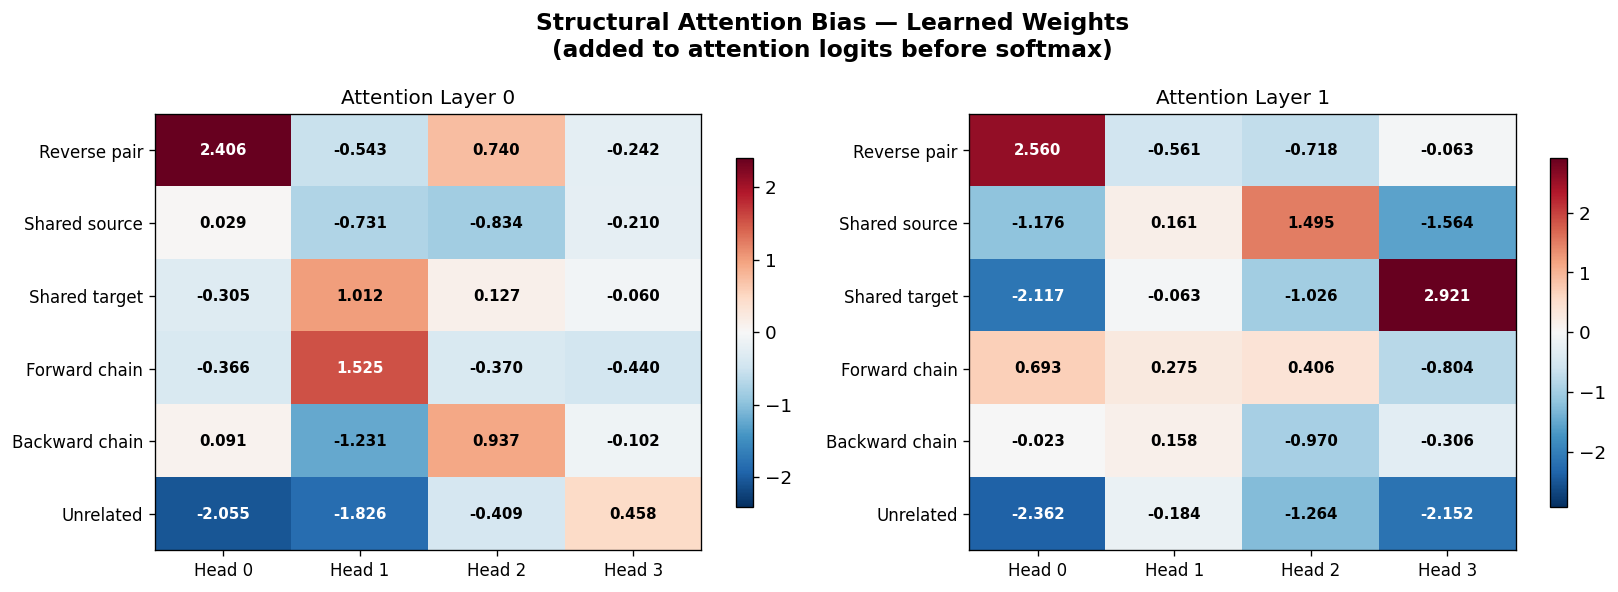

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Structural Attention Bias — Learned Weights\n"
             "(added to attention logits before softmax)",
             fontsize=14, fontweight="bold")

for layer_idx in range(2):
    key = f"attn_layers.{layer_idx}.struct_bias.weight"
    if key not in state_dict:
        print(f"  [SKIP] {key} not found")
        continue

    W = state_dict[key].numpy()  # (6, 4)
    ax = axes[layer_idx]

    vmax = max(abs(W.min()), abs(W.max()))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(W, cmap="RdBu_r", norm=norm, aspect="auto")

    ax.set_xticks(range(4))
    ax.set_xticklabels([f"Head {i}" for i in range(4)], fontsize=10)
    ax.set_yticks(range(6))
    ax.set_yticklabels(STRUCT_TYPE_NAMES, fontsize=10)
    ax.set_title(f"Attention Layer {layer_idx}", fontsize=12)

    for i in range(6):
        for j in range(4):
            color = "white" if abs(W[i, j]) > vmax * 0.6 else "black"
            ax.text(j, i, f"{W[i, j]:.3f}", ha="center", va="center",
                    fontsize=9, color=color, fontweight="bold")

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_structural_bias.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Print summary table
for layer_idx in range(2):
    key = f"attn_layers.{layer_idx}.struct_bias.weight"
    if key not in state_dict:
        continue
    W = state_dict[key].numpy()
    print(f"\nLayer {layer_idx} structural bias:")
    print(f"  {'Type':<20s}  {'Head0':>7s} {'Head1':>7s} {'Head2':>7s} {'Head3':>7s}  {'Mean':>7s}")
    print("  " + "-" * 65)
    for i, name in enumerate(STRUCT_TYPE_NAMES):
        vals = "  ".join(f"{w:+.4f}" for w in W[i])
        print(f"  {name:<20s}  {vals}  {W[i].mean():+.4f}")


Layer 0 structural bias:
  Type                    Head0   Head1   Head2   Head3     Mean
  -----------------------------------------------------------------
  Reverse pair          +2.4061  -0.5433  +0.7398  -0.2417  +0.5903
  Shared source         +0.0287  -0.7306  -0.8344  -0.2104  -0.4367
  Shared target         -0.3047  +1.0116  +0.1271  -0.0602  +0.1934
  Forward chain         -0.3663  +1.5247  -0.3698  -0.4398  +0.0872
  Backward chain        +0.0908  -1.2305  +0.9373  -0.1016  -0.0760
  Unrelated             -2.0547  -1.8264  -0.4088  +0.4585  -0.9579

Layer 1 structural bias:
  Type                    Head0   Head1   Head2   Head3     Mean
  -----------------------------------------------------------------
  Reverse pair          +2.5597  -0.5613  -0.7184  -0.0634  +0.3042
  Shared source         -1.1763  +0.1610  +1.4946  -1.5638  -0.2711
  Shared target         -2.1173  -0.0629  -1.0258  +2.9206  -0.0714
  Forward chain         +0.6927  +0.2750  +0.4063  -0.8037  +0.1426
  

## 2. Stem Layer — Channel Importance

The stem projects 8 input channels into d=64. The L2 norm per channel column tells us how much each channel contributes to the initial representation.

**Key question:** Are ANM residuals or kernel regression coefficients more important?

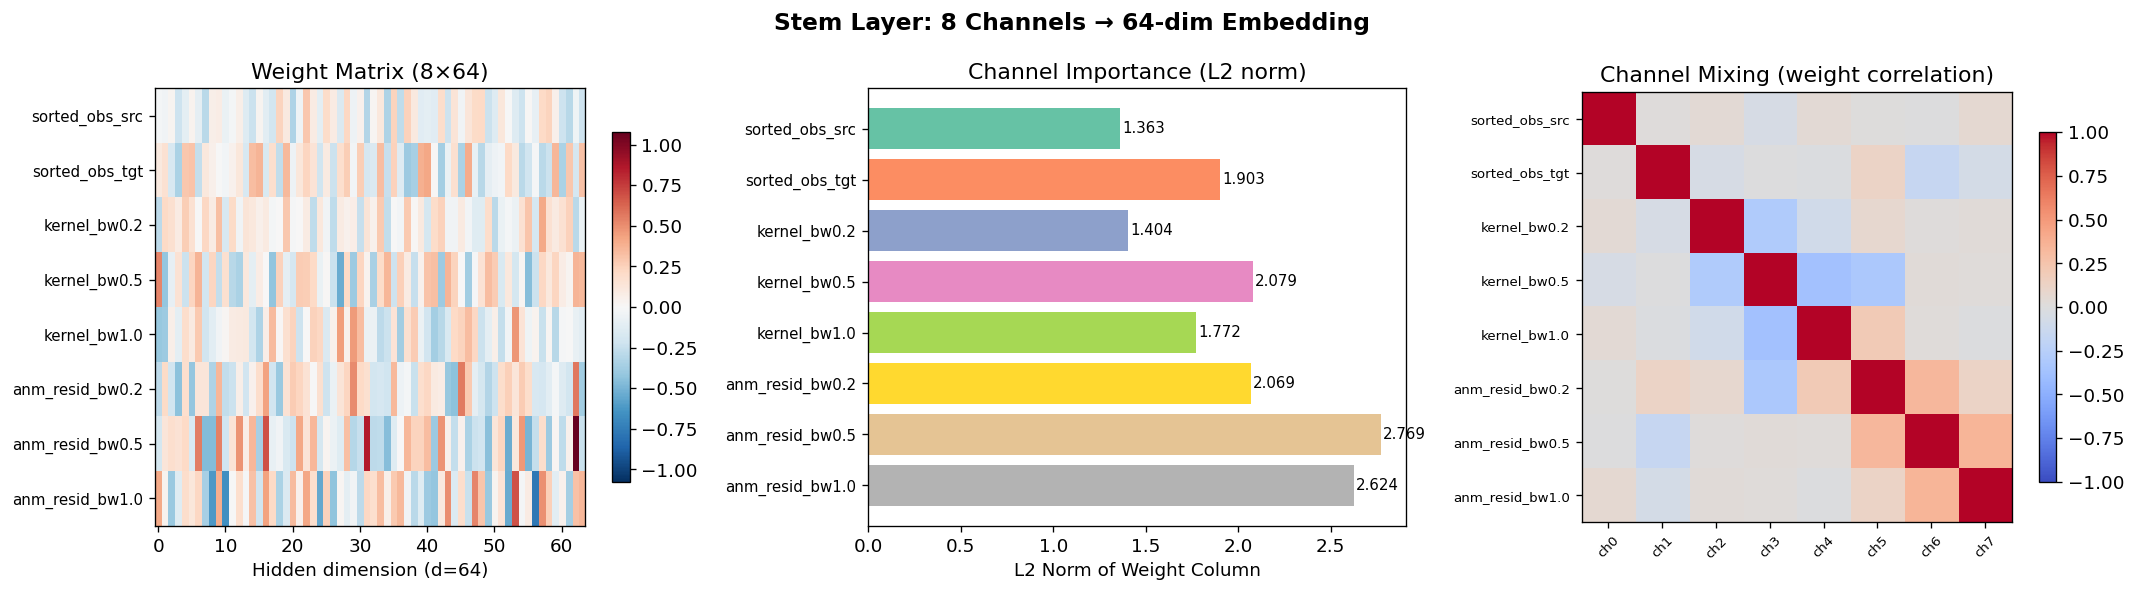

In [6]:
key = "extractor.stem.linear.weight"
assert key in state_dict, f"{key} not found"
W = state_dict[key].numpy()  # (64, 8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Stem Layer: 8 Channels → 64-dim Embedding", fontsize=14, fontweight="bold")

# (a) Full weight matrix heatmap
ax = axes[0]
vmax = max(abs(W.min()), abs(W.max()))
im = ax.imshow(W.T, cmap="RdBu_r", aspect="auto",
               norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax))
ax.set_xlabel("Hidden dimension (d=64)")
ax.set_yticks(range(8))
ax.set_yticklabels(CHANNEL_NAMES, fontsize=9)
ax.set_title("Weight Matrix (8×64)")
plt.colorbar(im, ax=ax, shrink=0.8)

# (b) Per-channel L2 norm (importance)
ax = axes[1]
norms = np.linalg.norm(W, axis=0)  # (8,)
colors = plt.cm.Set2(np.arange(8) / 8)
bars = ax.barh(range(8), norms, color=colors)
ax.set_yticks(range(8))
ax.set_yticklabels(CHANNEL_NAMES, fontsize=9)
ax.set_xlabel("L2 Norm of Weight Column")
ax.set_title("Channel Importance (L2 norm)")
ax.invert_yaxis()
for bar, val in zip(bars, norms):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

# (c) Channel correlation matrix
ax = axes[2]
corr = np.corrcoef(W.T)  # (8, 8)
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(8))
ax.set_xticklabels([f"ch{i}" for i in range(8)], fontsize=8, rotation=45)
ax.set_yticks(range(8))
ax.set_yticklabels(CHANNEL_NAMES, fontsize=8)
ax.set_title("Channel Mixing (weight correlation)")
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_stem_weights.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Conv1d Filter Analysis

5 residual ConvBlocks with Conv1d(64, 64, kernel_size=3). Each block's filter has shape (64, 64, 3).

**Key question:** Do filters evolve from smoothing (early) to edge-detection (late)? Or identity-like throughout?

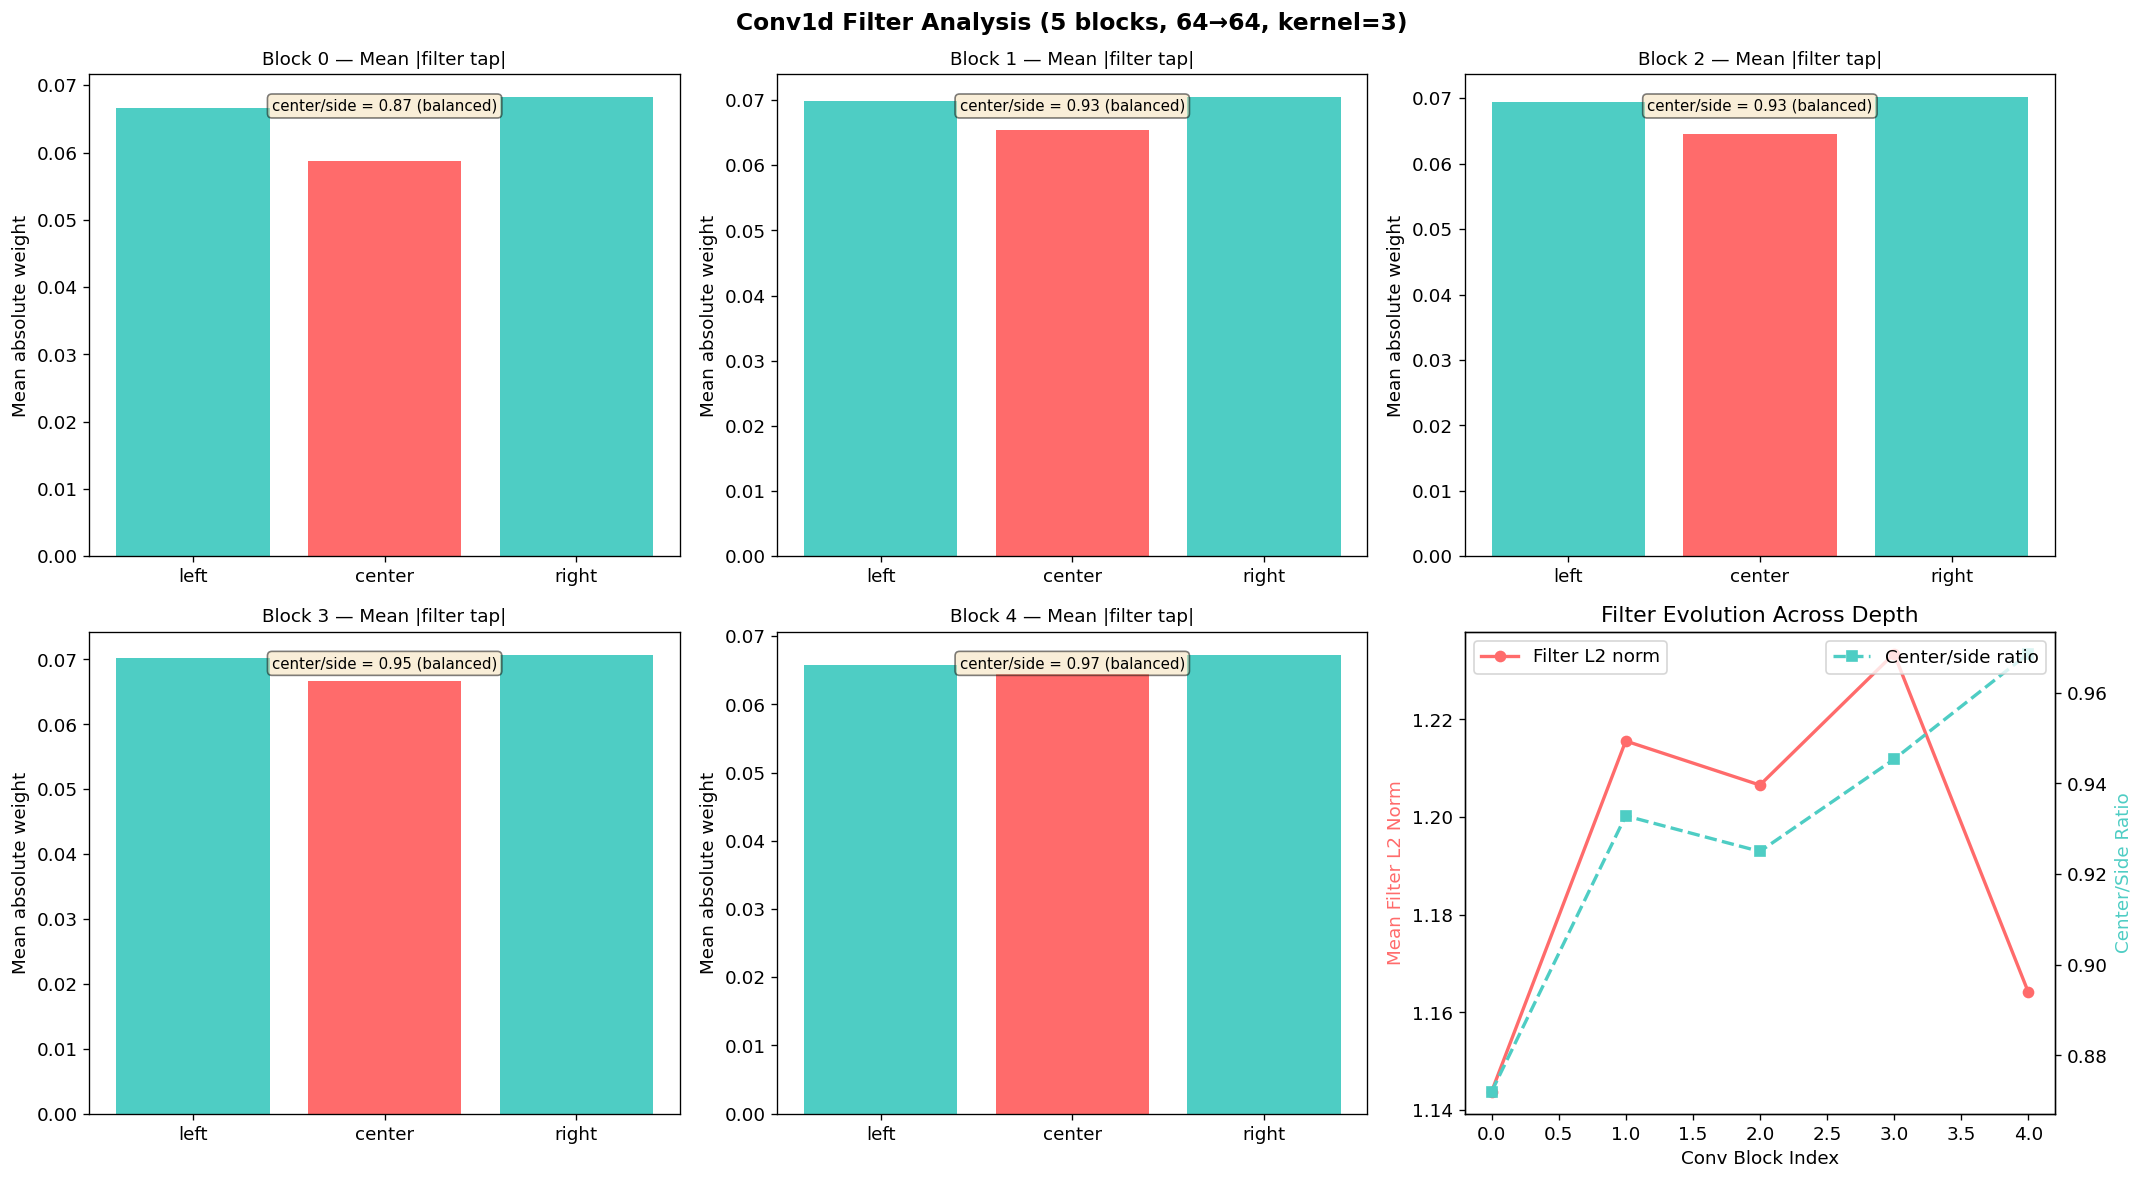

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Conv1d Filter Analysis (5 blocks, 64→64, kernel=3)",
             fontsize=14, fontweight="bold")

filter_stats = []

for block_idx in range(5):
    key = f"extractor.blocks.{block_idx}.conv.weight"
    if key not in state_dict:
        print(f"  [SKIP] {key}")
        continue

    W = state_dict[key].numpy()  # (64, 64, 3)

    filt_norms = np.linalg.norm(W, axis=(1, 2))
    center_weight = np.abs(W[:, :, 1]).mean()
    side_weight = (np.abs(W[:, :, 0]).mean() + np.abs(W[:, :, 2]).mean()) / 2

    filter_stats.append({
        "block": block_idx,
        "mean_norm": filt_norms.mean(),
        "center_weight": center_weight,
        "side_weight": side_weight,
        "center_to_side_ratio": center_weight / (side_weight + 1e-8),
    })

    row, col = divmod(block_idx, 3)
    ax = axes[row][col]

    mean_profile = np.abs(W).mean(axis=(0, 1))  # (3,)
    ax.bar(["left", "center", "right"], mean_profile,
           color=["#4ECDC4", "#FF6B6B", "#4ECDC4"])
    ax.set_title(f"Block {block_idx} — Mean |filter tap|", fontsize=11)
    ax.set_ylabel("Mean absolute weight")

    ratio = center_weight / (side_weight + 1e-8)
    ftype = "identity-like" if ratio > 2 else "smoothing" if ratio < 0.8 else "balanced"
    ax.text(0.5, 0.95, f"center/side = {ratio:.2f} ({ftype})",
            transform=ax.transAxes, ha="center", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# Last subplot: evolution across depth
if len(filter_stats) >= 5:
    ax = axes[1][2]
    blocks = [s["block"] for s in filter_stats]
    norms = [s["mean_norm"] for s in filter_stats]
    ratios = [s["center_to_side_ratio"] for s in filter_stats]

    ax.plot(blocks, norms, "o-", color="#FF6B6B", label="Filter L2 norm", linewidth=2)
    ax2 = ax.twinx()
    ax2.plot(blocks, ratios, "s--", color="#4ECDC4", label="Center/side ratio", linewidth=2)
    ax.set_xlabel("Conv Block Index")
    ax.set_ylabel("Mean Filter L2 Norm", color="#FF6B6B")
    ax2.set_ylabel("Center/Side Ratio", color="#4ECDC4")
    ax.set_title("Filter Evolution Across Depth")
    ax.legend(loc="upper left"); ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_conv_filters.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Edge Type Embeddings

7 edge types × d=64. Cosine similarity reveals which types the model treats as equivalent.

**Key question:** Do X-related and Y-related edge types form separate clusters?

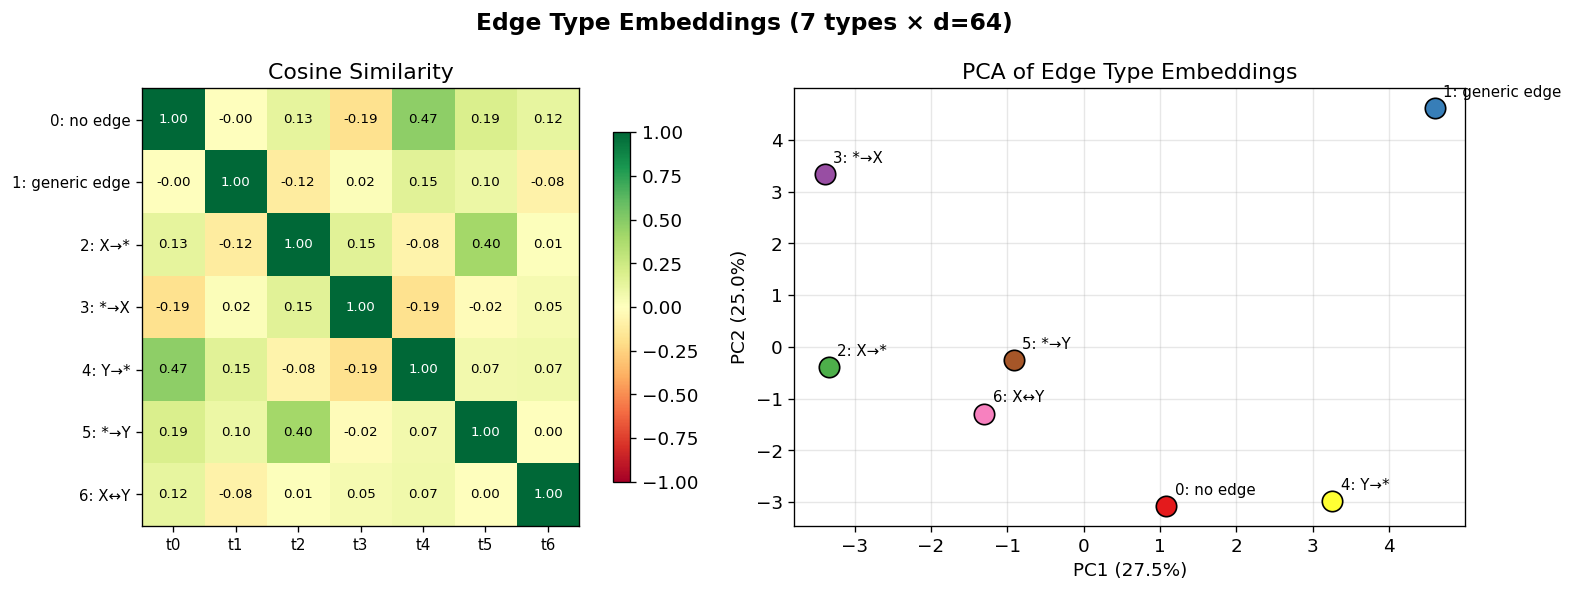

In [8]:
from sklearn.decomposition import PCA

key = "edge_type_emb.weight"
assert key in state_dict, f"{key} not found"
W = state_dict[key].numpy()  # (7, 64)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Edge Type Embeddings (7 types × d=64)", fontsize=14, fontweight="bold")

# (a) Cosine similarity
ax = axes[0]
W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-8)
sim = W_norm @ W_norm.T
im = ax.imshow(sim, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(7))
ax.set_xticklabels([f"t{i}" for i in range(7)], fontsize=9)
ax.set_yticks(range(7))
ax.set_yticklabels(EDGE_TYPE_NAMES, fontsize=9)
ax.set_title("Cosine Similarity")
for i in range(7):
    for j in range(7):
        color = "white" if abs(sim[i, j]) > 0.6 else "black"
        ax.text(j, i, f"{sim[i,j]:.2f}", ha="center", va="center",
                fontsize=8, color=color)
plt.colorbar(im, ax=ax, shrink=0.8)

# (b) PCA
ax = axes[1]
pca = PCA(n_components=2)
coords = pca.fit_transform(W)
colors = plt.cm.Set1(np.arange(7) / 7)
for i in range(7):
    ax.scatter(coords[i, 0], coords[i, 1], c=[colors[i]], s=150,
               edgecolors="black", linewidth=1, zorder=5)
    ax.annotate(EDGE_TYPE_NAMES[i], (coords[i, 0], coords[i, 1]),
                fontsize=9, ha="left", va="bottom",
                xytext=(5, 5), textcoords="offset points")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA of Edge Type Embeddings")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_edge_type_emb.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Node Head — Edge Direction Importance Per Class

The node head gathers 4 edges: `[v→X, v→Y, X→v, Y→v]` → MergeOperator(4d→d) → Linear(d→8).

We decompose the merge weight into 4 blocks and compute the effective importance per class.

**Expected patterns:**
- **Confounder** (v→X, v→Y): should weight outgoing edges from v
- **Collider** (X→v, Y→v): should weight incoming edges to v
- **Mediator** (X→v AND v→Y): needs both directions
- **CauseX / ConseqX**: should be asymmetric between X-edges and Y-edges

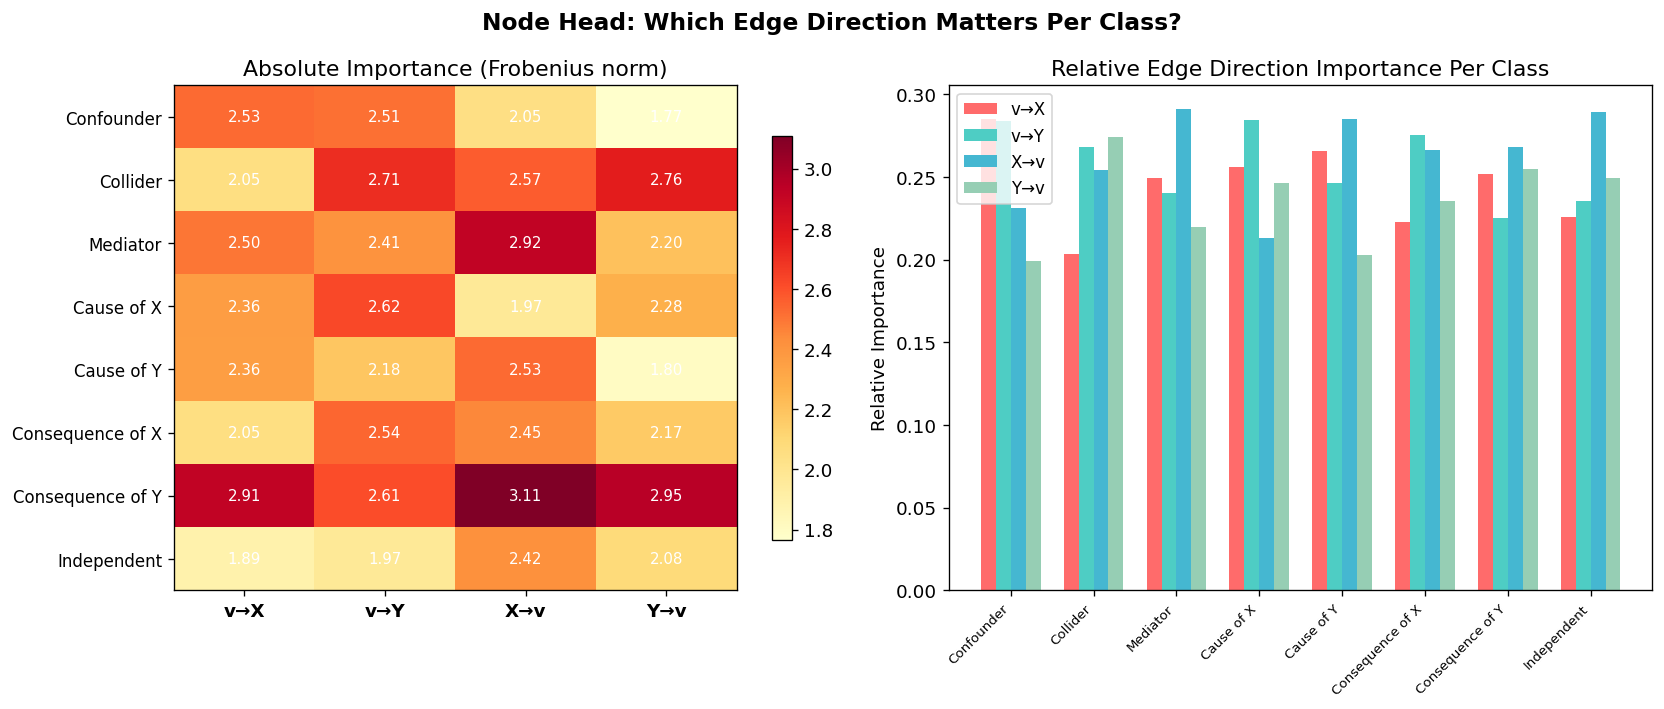

In [9]:
merge_key = "node_merge.linear.weight"  # (d, 4*d)
head_key = "node_head.weight"            # (8, d)

assert merge_key in state_dict and head_key in state_dict

W_merge = state_dict[merge_key].numpy()  # (d, 4d)
W_head = state_dict[head_key].numpy()    # (8, d)
d = W_head.shape[1]

edge_dir_names = ["v→X", "v→Y", "X→v", "Y→v"]
blocks = [W_merge[:, i*d:(i+1)*d] for i in range(4)]  # each (d, d)

importance = np.zeros((8, 4))
for j, block in enumerate(blocks):
    effective = W_head @ block  # (8, d)
    importance[:, j] = np.linalg.norm(effective, axis=1)

importance_rel = importance / (importance.sum(axis=1, keepdims=True) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Node Head: Which Edge Direction Matters Per Class?",
             fontsize=14, fontweight="bold")

# (a) Absolute importance
ax = axes[0]
im = ax.imshow(importance, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(edge_dir_names, fontsize=11, fontweight="bold")
ax.set_yticks(range(8))
ax.set_yticklabels(CLASS_NAMES, fontsize=10)
ax.set_title("Absolute Importance (Frobenius norm)")
for i in range(8):
    for j in range(4):
        ax.text(j, i, f"{importance[i,j]:.2f}", ha="center", va="center",
                fontsize=9,
                color="white" if importance[i,j] > importance.max()*0.5 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)

# (b) Relative importance
ax = axes[1]
x = np.arange(8)
width = 0.18
bar_colors = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4"]
for j in range(4):
    ax.bar(x + j*width, importance_rel[:, j], width,
           label=edge_dir_names[j], color=bar_colors[j])
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(CLASS_NAMES, fontsize=8, rotation=45, ha="right")
ax.set_ylabel("Relative Importance")
ax.set_title("Relative Edge Direction Importance Per Class")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_node_head_weights.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Part 2: Activation-Level Analysis

**Requires GPU + preprocessed data cache.** We run inference with hooks to collect per-class embeddings.

In [10]:
# Import v11 module
sys.path.insert(0, str(SRC_DIR))
v11 = __import__(V11_MODULE)
print(f"Imported {V11_MODULE}")

# Build model and load weights
model = v11.ADIAModel()
model.load_state_dict(state_dict, strict=False)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Model on {device}")

Imported v11_structbias_xyaug
Model on cuda


In [11]:
# Load test data
assert X_TEST_PATH.exists(), f"Not found: {X_TEST_PATH}"
assert Y_TEST_PATH.exists(), f"Not found: {Y_TEST_PATH}"

with open(X_TEST_PATH, "rb") as f:
    X_test = pickle.load(f)
with open(Y_TEST_PATH, "rb") as f:
    y_test = pickle.load(f)

print(f"Loaded {len(X_test)} test graphs, {len(y_test)} label matrices")

/tmp/ipykernel_395690/801675224.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  X_test = pickle.load(f)


Loaded 1880 test graphs, 1880 label matrices


/tmp/ipykernel_395690/801675224.py:8: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  y_test = pickle.load(f)


In [12]:
# Check for preprocessed cache
# Adjust the cache filename to match your actual cache
import glob

cache_dir = SRC_DIR / "dataset_cache"
if cache_dir.exists():
    caches = sorted(cache_dir.glob("infer_*.pkl"))
    print(f"Available caches in {cache_dir}:")
    for c in caches:
        size_mb = c.stat().st_size / 1e6
        print(f"  {c.name:40s} ({size_mb:.0f} MB)")
else:
    print(f"No cache directory found at {cache_dir}")
    print("You'll need to preprocess the data first.")

Available caches in /data/anhld48/phatnt/Graduation-Thesis-BsC-2026/src/dataset_cache:
  infer_v11_structbias_nk1000.pkl          (3766 MB)
  infer_v21_partial_nk1000.pkl             (4707 MB)
  infer_v25_nk1000.pkl                     (4042 MB)
  infer_v25a_nk1000.pkl                    (3955 MB)
  infer_v25b_nk1000.pkl                    (3955 MB)
  infer_v26c_nk1000.pkl                    (377 MB)
  infer_v26d_noch8_ss5.0_as2.0.pkl         (4143 MB)
  infer_v27_nk1000.pkl                     (1929 MB)
  infer_v28_nk1000.pkl                     (377 MB)
  infer_v29_nk1000.pkl                     (3857 MB)
  infer_v30_nk1000.pkl                     (4143 MB)


In [ ]:
# ============================================================
# Load cached dataset — ADJUST THIS PATH
# ============================================================
CACHE_PATH = cache_dir / "infer_v11_structbias_nk1000.pkl"  # <-- adjust!

assert CACHE_PATH.exists(), (
    f"Cache not found: {CACHE_PATH}\n"
    f"Either adjust the path above or run preprocessing first."
)

with open(CACHE_PATH, "rb") as f:
    cached_data = pickle.load(f)

dataset_items = cached_data if isinstance(cached_data, list) else list(cached_data.values())
print(f"Loaded {len(dataset_items)} cached items")
print(f"Keys per item: {list(dataset_items[0].keys())}")

Loaded 1880 cached items
Keys per item: ['edge_data', 'edge_types', 'cols', 'p']


In [25]:
# Attach ground truth labels
adjacency_label = v11.get_adjacency_label()

n_labeled = 0
y_test_keys = list(y_test.keys())

for i, item in enumerate(dataset_items):
    if i >= len(y_test):
        break
    y_df = y_test[y_test_keys[i]]
    cols = item.get("cols", list(y_df.columns))
    arr = y_df.values
    col_idx = {c: j for j, c in enumerate(cols)}

    # Edge labels
    p = len(cols)
    edge_labels = []
    for ui in range(p):
        for vi in range(p):
            if ui != vi:
                edge_labels.append(int(arr[ui, vi]))
    item["edge_labels"] = np.array(edge_labels, dtype=np.int64)

    # Node labels
    node_labels = []
    for v in cols:
        if v in ("X", "Y"):
            continue
        idx = [col_idx[v], col_idx["X"], col_idx["Y"]]
        sub = arr[np.ix_(idx, idx)]
        key = tuple(sub.flatten())
        label_str = adjacency_label.get(key, "Independent")
        node_labels.append(v11.CLASS_NAMES.index(label_str))
    item["node_labels"] = np.array(node_labels, dtype=np.int64)
    n_labeled += 1

print(f"Labeled {n_labeled} items")

Labeled 1880 items


In [27]:
# ============================================================
# Collect activations via forward hooks
# ============================================================
from torch.utils.data import DataLoader


class HookedCollector:
    """Attaches hooks to capture post-attention embeddings."""
    def __init__(self, model):
        self.activations = {}
        self.hooks = []
        # Hook last attention layer
        for i, attn in enumerate(model.attn_layers):
            name = f"post_attn_{i}"
            self.hooks.append(
                attn.register_forward_hook(self._make_hook(name))
            )

    def _make_hook(self, name):
        def fn(module, inp, out):
            self.activations[name] = out.detach().cpu()
        return fn

    def clear(self):
        self.activations.clear()

    def detach(self):
        for h in self.hooks:
            h.remove()

# Convert numpy arrays to torch tensors (cache stores numpy, collate expects torch)
for item in dataset_items:
    for k, v in item.items():
        if isinstance(v, np.ndarray):
            if v.dtype in (np.float32, np.float64):
                item[k] = torch.from_numpy(v).float()
            elif v.dtype in (np.int32, np.int64):
                item[k] = torch.from_numpy(v).long()

print("Converted numpy arrays to torch tensors")


collector = HookedCollector(model)

loader = DataLoader(dataset_items, batch_size=32, shuffle=False,
                    collate_fn=v11.collate_fn, num_workers=0)

all_node_embs = []       # (N, 4*d)
all_node_labels = []     # (N,)
post_attn_by_class = defaultdict(list)

with torch.no_grad():
    for batch_idx, batch in enumerate(loader):
        if batch_idx >= MAX_BATCHES:
            break

        edge_data = batch["edge_data"].to(device)
        edge_types = batch["edge_types"].to(device)
        edge_mask = batch["edge_mask"].to(device)
        cols_list = batch["cols"]
        struct_rel = batch.get("struct_rel")
        if struct_rel is not None:
            struct_rel = struct_rel.to(device)

        collector.clear()
        edge_logits, node_logits_list = model(
            edge_data, edge_types, edge_mask, cols_list,
            struct_rel=struct_rel,
        )

        post_attn = collector.activations.get("post_attn_1",
                    collector.activations.get("post_attn_0"))
        B = edge_data.shape[0]

        if "node_labels" not in batch:
            continue
        nl = batch["node_labels"]

        for b in range(B):
            cols = cols_list[b]
            p = len(cols)
            col_idx = {name: i for i, name in enumerate(cols)}
            edge_order = {}
            count = 0
            for ui in range(p):
                for vi in range(p):
                    if ui != vi:
                        edge_order[(ui, vi)] = count
                        count += 1

            x_idx = col_idx.get("X")
            y_idx = col_idx.get("Y")
            if x_idx is None or y_idx is None:
                continue

            other_nodes = [n for n in cols if n not in ("X", "Y")]
            for vi, node_name in enumerate(other_nodes):
                label = nl[b, vi].item()
                if label < 0:
                    continue

                u = col_idx[node_name]
                e_vx = post_attn[b, edge_order[(u, x_idx)]].numpy()
                e_vy = post_attn[b, edge_order[(u, y_idx)]].numpy()
                e_xv = post_attn[b, edge_order[(x_idx, u)]].numpy()
                e_yv = post_attn[b, edge_order[(y_idx, u)]].numpy()

                all_node_embs.append(np.concatenate([e_vx, e_vy, e_xv, e_yv]))
                all_node_labels.append(label)
                for emb in [e_vx, e_vy, e_xv, e_yv]:
                    post_attn_by_class[label].append(emb)

        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx + 1}/{MAX_BATCHES}, "
                  f"{len(all_node_labels)} nodes collected")

collector.detach()

all_node_embs = np.array(all_node_embs)
all_node_labels = np.array(all_node_labels)
post_attn_by_class = {k: np.array(v) for k, v in post_attn_by_class.items()}

print(f"\nCollected {len(all_node_labels)} nodes total")
for cls in range(N_CLASSES):
    n = (all_node_labels == cls).sum()
    n_embs = len(post_attn_by_class.get(cls, []))
    print(f"  {CLASS_NAMES[cls]:20s}: {n:5d} nodes, {n_embs:5d} edge embs")

Converted numpy arrays to torch tensors
  Batch 50/200, 9784 nodes collected

Collected 11486 nodes total
  Confounder          :   682 nodes,  2728 edge embs
  Collider            :   446 nodes,  1784 edge embs
  Mediator            :   483 nodes,  1932 edge embs
  Cause of X          :   983 nodes,  3932 edge embs
  Cause of Y          :  2145 nodes,  8580 edge embs
  Consequence of X    :  1571 nodes,  6284 edge embs
  Consequence of Y    :   682 nodes,  2728 edge embs
  Independent         :  4494 nodes, 17976 edge embs


## 6. t-SNE of Node Embeddings

Each node is represented by concatenating its 4 edge embeddings: `[e_vX, e_vY, e_Xv, e_Yv]` → 256-dim.

**Key question:** Do the 8 classes form separable clusters? Where do Mediators overlap with Confounders?

Running t-SNE on 5000 samples (dim=256)...


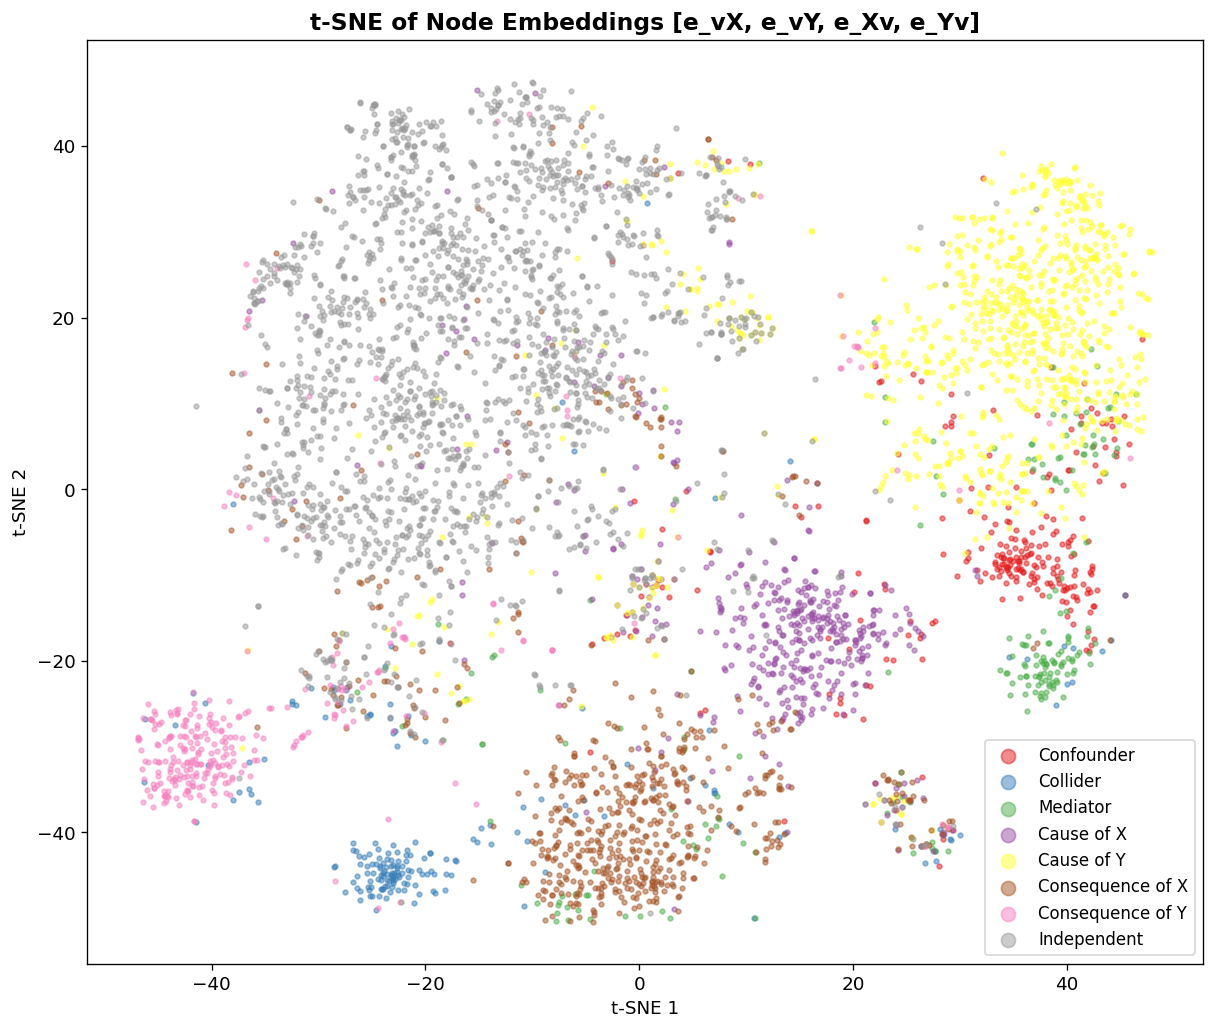

In [29]:
from sklearn.manifold import TSNE

N = len(all_node_labels)
if N > MAX_TSNE_SAMPLES:
    idx = np.random.choice(N, MAX_TSNE_SAMPLES, replace=False)
    tsne_embs = all_node_embs[idx]
    tsne_labels = all_node_labels[idx]
else:
    tsne_embs = all_node_embs
    tsne_labels = all_node_labels

print(f"Running t-SNE on {len(tsne_labels)} samples (dim={tsne_embs.shape[1]})...")
coords = TSNE(n_components=2, perplexity=50, max_iter=1000,
              random_state=42).fit_transform(tsne_embs)

fig, ax = plt.subplots(figsize=(12, 10))
colors = plt.cm.Set1(np.linspace(0, 1, N_CLASSES))

for cls in range(N_CLASSES):
    mask = tsne_labels == cls
    if mask.sum() == 0:
        continue
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[colors[cls]], s=8, alpha=0.5, label=CLASS_NAMES[cls])

ax.legend(fontsize=10, markerscale=3)
ax.set_title("t-SNE of Node Embeddings [e_vX, e_vY, e_Xv, e_Yv]",
             fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")

plt.savefig(OUTPUT_DIR / "06_tsne_node_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Per-Class Activation Fingerprints

Mean edge embedding (d=64) per class + Fisher discriminability per dimension.

**Key question:** Which embedding dimensions carry the most class-diagnostic information?

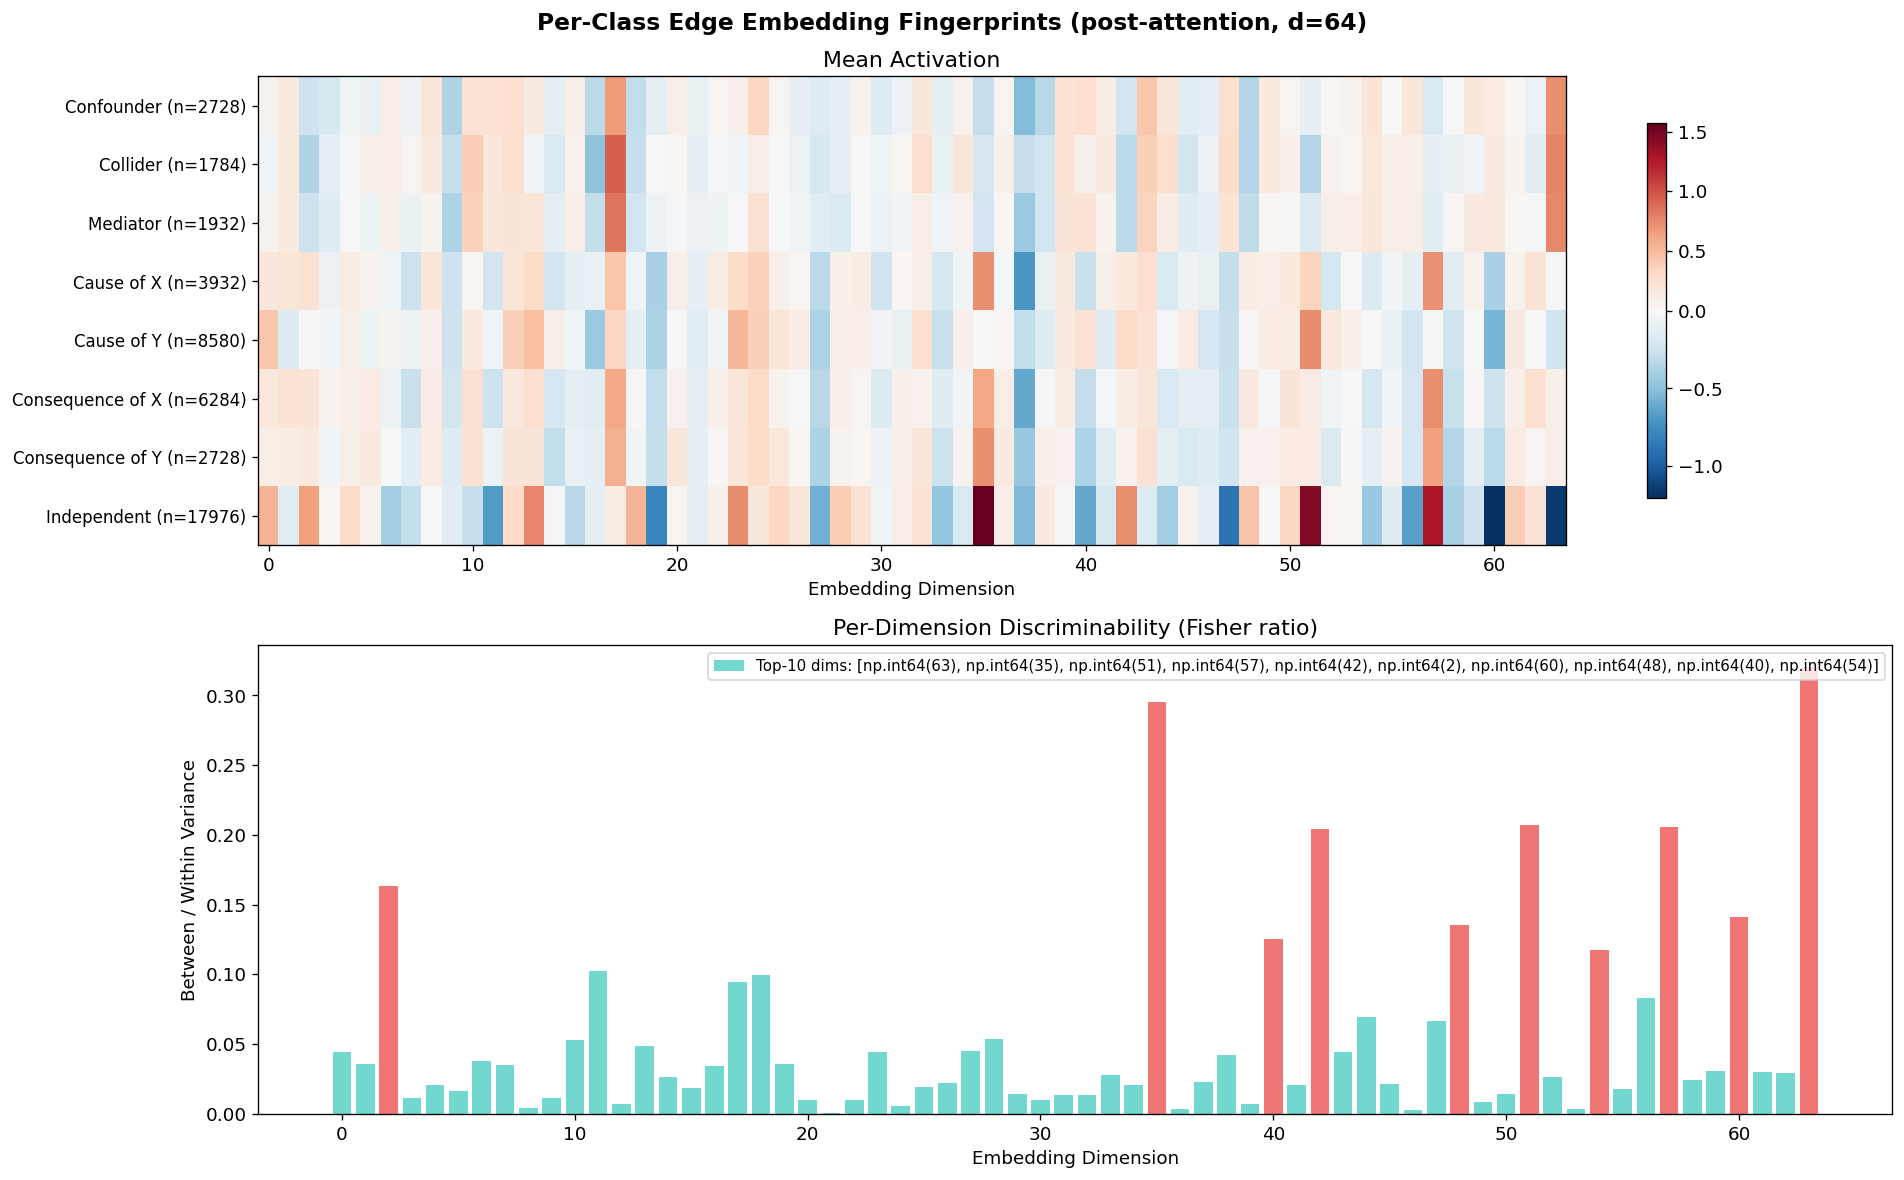

In [30]:
d_emb = list(post_attn_by_class.values())[0].shape[1]

mean_act = np.zeros((N_CLASSES, d_emb))
std_act = np.zeros((N_CLASSES, d_emb))
counts = np.zeros(N_CLASSES)

for cls in range(N_CLASSES):
    if cls in post_attn_by_class and len(post_attn_by_class[cls]) > 0:
        embs = post_attn_by_class[cls]
        mean_act[cls] = embs.mean(axis=0)
        std_act[cls] = embs.std(axis=0)
        counts[cls] = len(embs)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle("Per-Class Edge Embedding Fingerprints (post-attention, d=64)",
             fontsize=14, fontweight="bold")

# (a) Mean activation per class
ax = axes[0]
im = ax.imshow(mean_act, cmap="RdBu_r", aspect="auto",
               norm=TwoSlopeNorm(vmin=mean_act.min(), vcenter=0, vmax=mean_act.max()))
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels([f"{CLASS_NAMES[i]} (n={int(counts[i])})" for i in range(N_CLASSES)],
                   fontsize=10)
ax.set_xlabel("Embedding Dimension")
ax.set_title("Mean Activation")
plt.colorbar(im, ax=ax, shrink=0.8)

# (b) Fisher discriminability
ax = axes[1]
between_var = mean_act.var(axis=0)
within_var = (std_act ** 2).mean(axis=0)
discriminability = between_var / (within_var + 1e-8)

ax.bar(range(d_emb), discriminability, color="#4ECDC4", alpha=0.8)
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Between / Within Variance")
ax.set_title("Per-Dimension Discriminability (Fisher ratio)")

top10 = np.argsort(discriminability)[-10:][::-1]
for dim in top10:
    ax.bar(dim, discriminability[dim], color="#FF6B6B", alpha=0.9)
ax.legend([f"Top-10 dims: {list(top10)}"], fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_class_fingerprints.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Inter-Class Embedding Distances

Cosine distance between class centroids + hierarchical clustering.

**Key question:** Which classes are closest in embedding space? This explains confusion patterns.

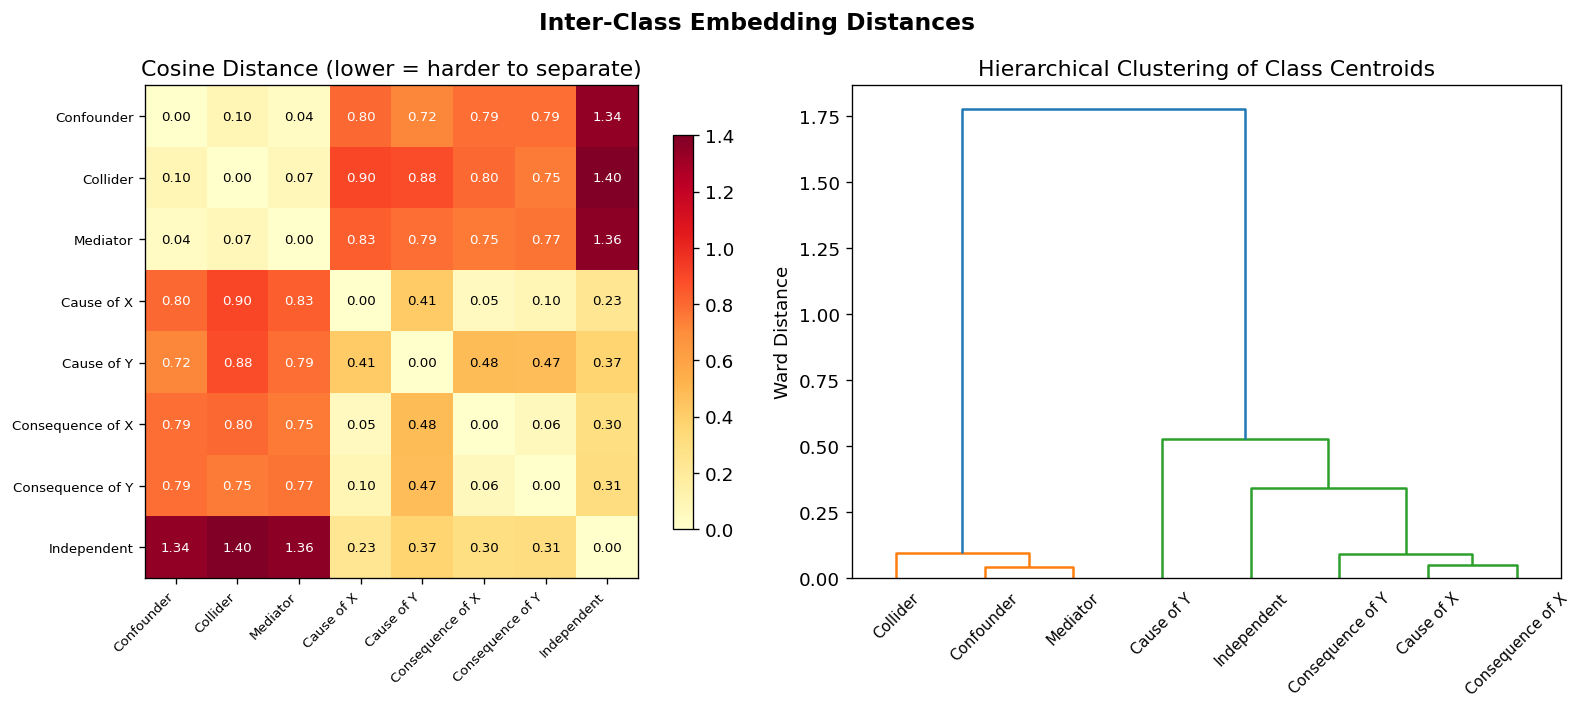

In [31]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

centroids = np.zeros((N_CLASSES, d_emb))
for cls in range(N_CLASSES):
    if cls in post_attn_by_class and len(post_attn_by_class[cls]) > 0:
        centroids[cls] = post_attn_by_class[cls].mean(axis=0)

norms = np.linalg.norm(centroids, axis=1, keepdims=True) + 1e-8
centroids_norm = centroids / norms
cos_sim = centroids_norm @ centroids_norm.T
cos_dist = 1 - cos_sim

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Inter-Class Embedding Distances", fontsize=14, fontweight="bold")

# (a) Cosine distance matrix
ax = axes[0]
im = ax.imshow(cos_dist, cmap="YlOrRd", vmin=0)
ax.set_xticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, fontsize=8, rotation=45, ha="right")
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_title("Cosine Distance (lower = harder to separate)")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        color = "white" if cos_dist[i, j] > cos_dist.max() * 0.5 else "black"
        ax.text(j, i, f"{cos_dist[i,j]:.2f}", ha="center", va="center",
                fontsize=8, color=color)
plt.colorbar(im, ax=ax, shrink=0.8)

# (b) Dendrogram
ax = axes[1]
np.fill_diagonal(cos_dist, 0)
cos_dist_sym = (cos_dist + cos_dist.T) / 2
condensed = squareform(cos_dist_sym)
Z = linkage(condensed, method="ward")
dendrogram(Z, labels=CLASS_NAMES, ax=ax, leaf_rotation=45, leaf_font_size=9)
ax.set_title("Hierarchical Clustering of Class Centroids")
ax.set_ylabel("Ward Distance")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_class_distances.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Bonus: Per-Direction Embedding Comparison

For each class, compare the 4 edge direction embeddings separately.
This answers: **does the model encode different information in v→X vs X→v?**

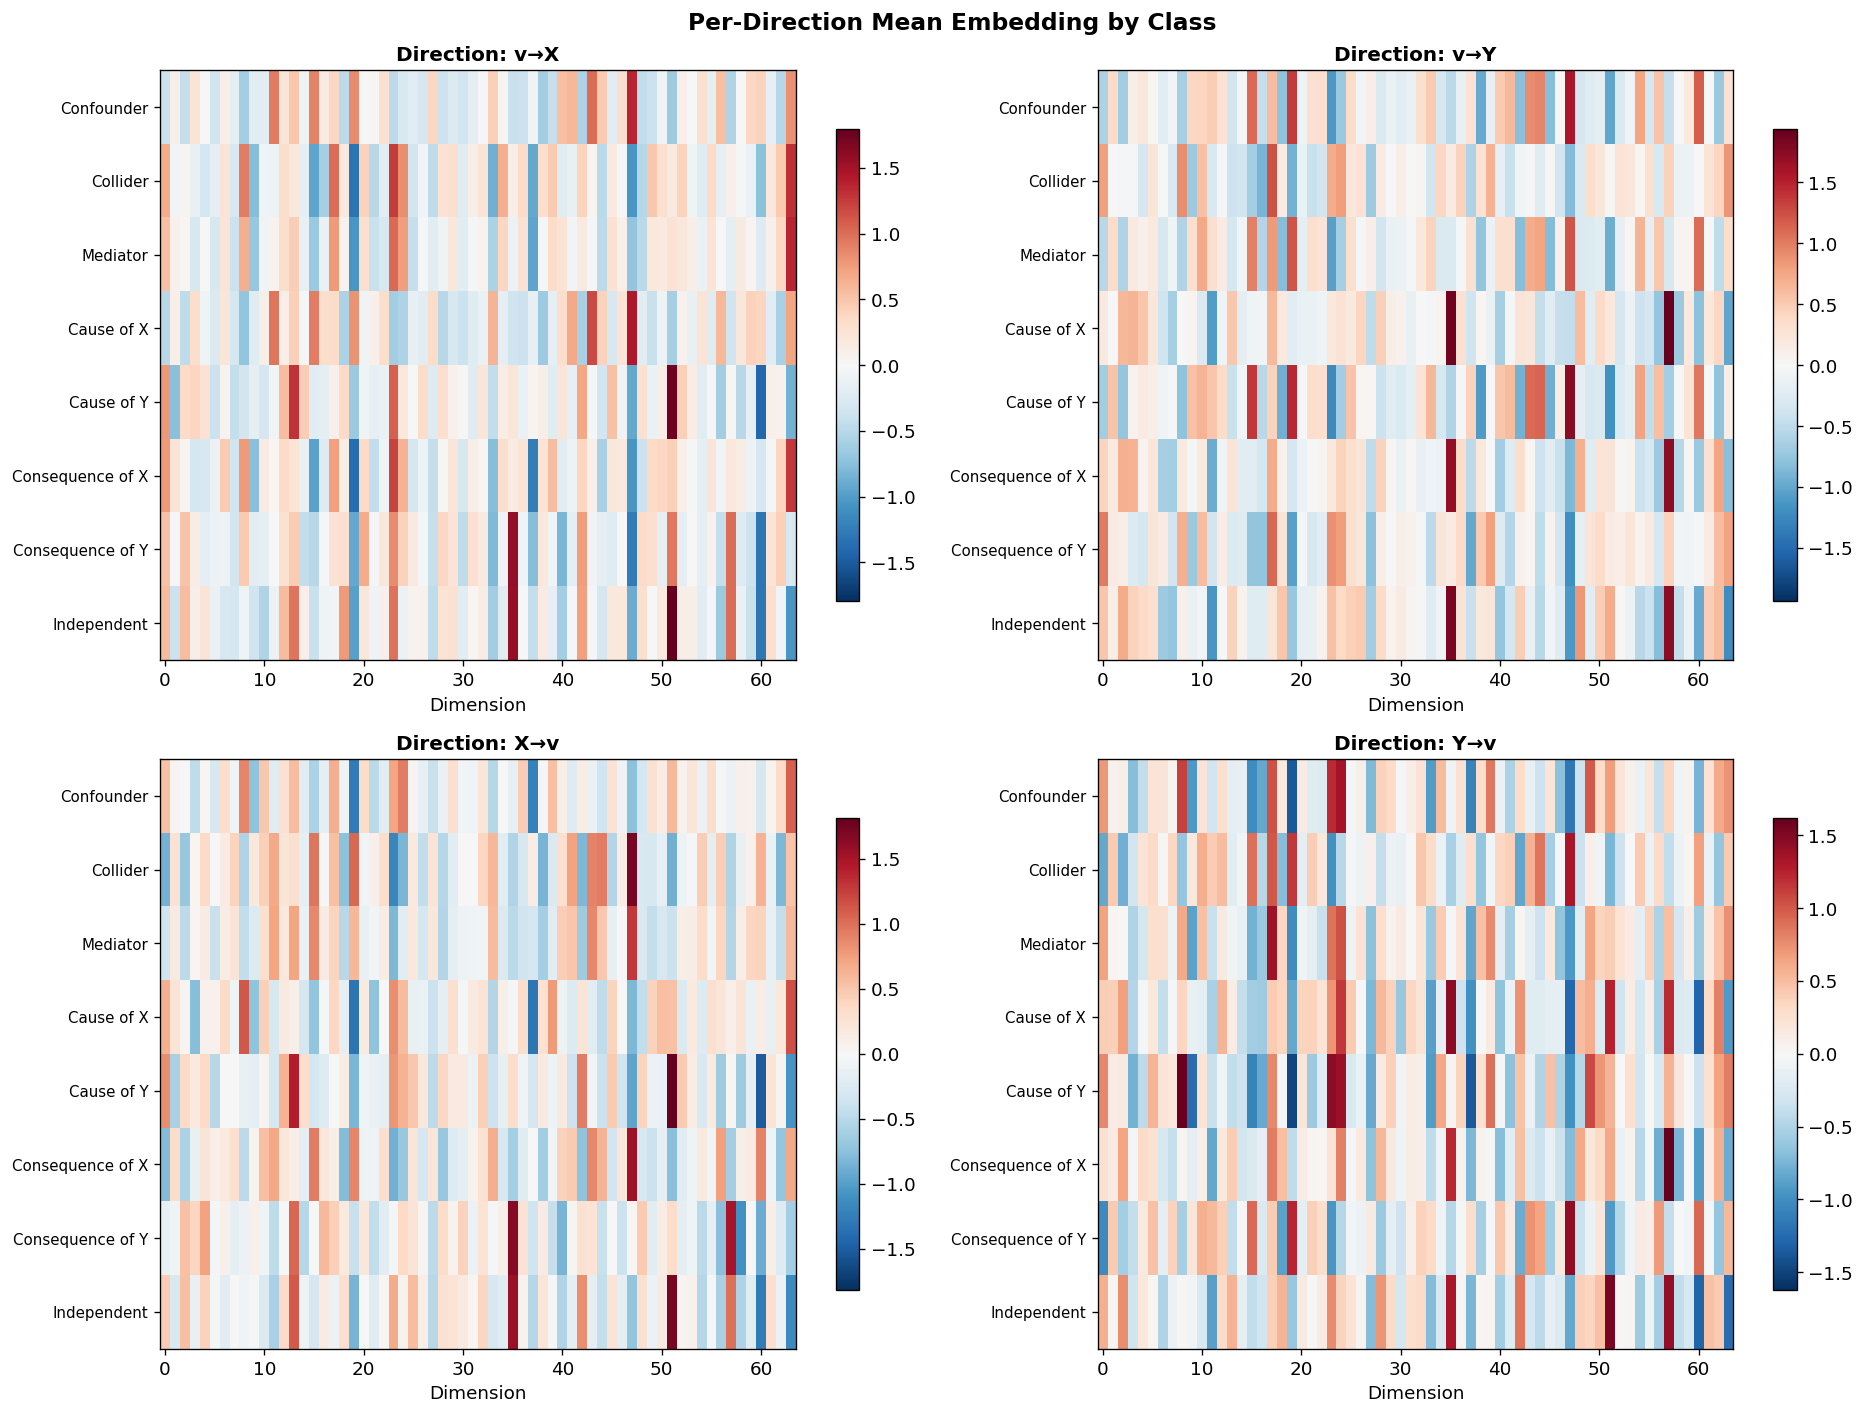

In [32]:
# Separate the 4-edge node embeddings back into directions
d_emb = all_node_embs.shape[1] // 4
dir_names = ["v→X", "v→Y", "X→v", "Y→v"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Per-Direction Mean Embedding by Class",
             fontsize=14, fontweight="bold")

for dir_idx in range(4):
    ax = axes[dir_idx // 2][dir_idx % 2]
    dir_embs = all_node_embs[:, dir_idx * d_emb : (dir_idx + 1) * d_emb]

    mean_per_class = np.zeros((N_CLASSES, d_emb))
    for cls in range(N_CLASSES):
        mask = all_node_labels == cls
        if mask.sum() > 0:
            mean_per_class[cls] = dir_embs[mask].mean(axis=0)

    vmax = max(abs(mean_per_class.min()), abs(mean_per_class.max()))
    im = ax.imshow(mean_per_class, cmap="RdBu_r", aspect="auto",
                   norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax))
    ax.set_yticks(range(N_CLASSES))
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel("Dimension")
    ax.set_title(f"Direction: {dir_names[dir_idx]}", fontsize=12, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_per_direction_fingerprints.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Directional Asymmetry Analysis

For each class, compute `||e_vX - e_Xv||` and `||e_vY - e_Yv||`. 
High asymmetry = strong directional signal. Confounders should have large v→X vs X→v asymmetry.

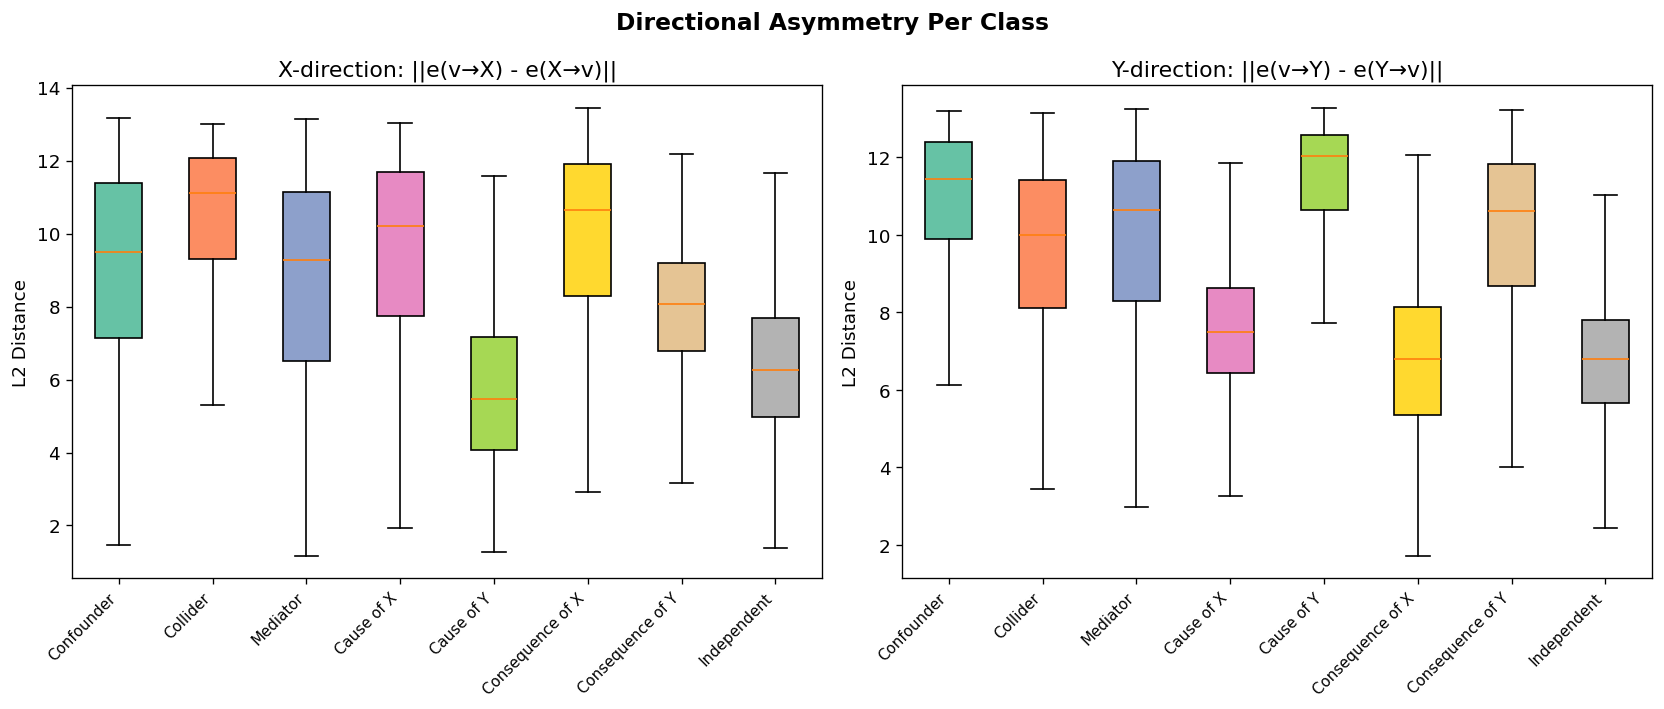

In [34]:
e_vx = all_node_embs[:, 0*d_emb : 1*d_emb]
e_vy = all_node_embs[:, 1*d_emb : 2*d_emb]
e_xv = all_node_embs[:, 2*d_emb : 3*d_emb]
e_yv = all_node_embs[:, 3*d_emb : 4*d_emb]

asym_x = np.linalg.norm(e_vx - e_xv, axis=1)  # ||v→X - X→v||
asym_y = np.linalg.norm(e_vy - e_yv, axis=1)  # ||v→Y - Y→v||

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Directional Asymmetry Per Class", fontsize=14, fontweight="bold")

for ax, asym, label in [
    (axes[0], asym_x, "X-direction: ||e(v→X) - e(X→v)||"),
    (axes[1], asym_y, "Y-direction: ||e(v→Y) - e(Y→v)||"),
]:
    data_per_class = []
    labels_for_box = []
    for cls in range(N_CLASSES):
        mask = all_node_labels == cls
        if mask.sum() > 0:
            data_per_class.append(asym[mask])
            labels_for_box.append(CLASS_NAMES[cls])

    bp = ax.boxplot(data_per_class, tick_labels=labels_for_box,
                    patch_artist=True, showfliers=False)
    colors = plt.cm.Set2(np.linspace(0, 1, len(data_per_class)))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    ax.set_xticklabels(labels_for_box, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("L2 Distance")
    ax.set_title(label)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_directional_asymmetry.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Summary

All outputs saved to `explore_outputs/`. Visualizations:

| # | File | What it shows |
|---|------|---------------|
| 01 | structural_bias | Learned topological priors (24 params) |
| 02 | stem_weights | Channel importance ranking |
| 03 | conv_filters | Filter type evolution across depth |
| 04 | edge_type_emb | Edge type similarity structure |
| 05 | node_head_weights | Per-class edge direction importance |
| 06 | tsne_node_embeddings | Class separability in embedding space |
| 07 | class_fingerprints | Mean activation + Fisher discriminability |
| 08 | class_distances | Inter-class cosine distance + dendrogram |
| 09 | per_direction_fingerprints | Direction-specific class signatures |
| 10 | directional_asymmetry | How much v→X differs from X→v per class |